In [47]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px 

In [48]:
historical_data = pd.read_csv("/mnt/shared/machine_learning/sum_data/gpu_price_history.csv")
metadata = pd.read_csv("/mnt/shared/machine_learning/sum_data/gpu_metadata.csv")

historical_data = historical_data[historical_data["Retail Price"] !=0]
historical_data.head(225)

,Date,Name,Retail Price,Used Price
2,01-03-23,GeForce GTX 1050,192,61
3,01-03-24,GeForce GTX 1050,254,52
4,01-04-23,GeForce GTX 1050,181,55
5,01-04-24,GeForce GTX 1050,254,52
6,01-05-23,GeForce GTX 1050,162,62
...,...,...,...,...
246,01-11-22,GeForce RTX 3060,367,255
247,01-11-23,GeForce RTX 3060,279,212
248,01-11-24,GeForce RTX 3060,280,202
249,01-12-22,GeForce RTX 3060,362,264


In [49]:
all_gpu_performance_data = metadata[["Name", "3DMARK"]]

Text(0.5, 1.0, 'Gpu Performance Score Nvidia(pascal to lovelace), AMD(pirate island to RDNA 3)')

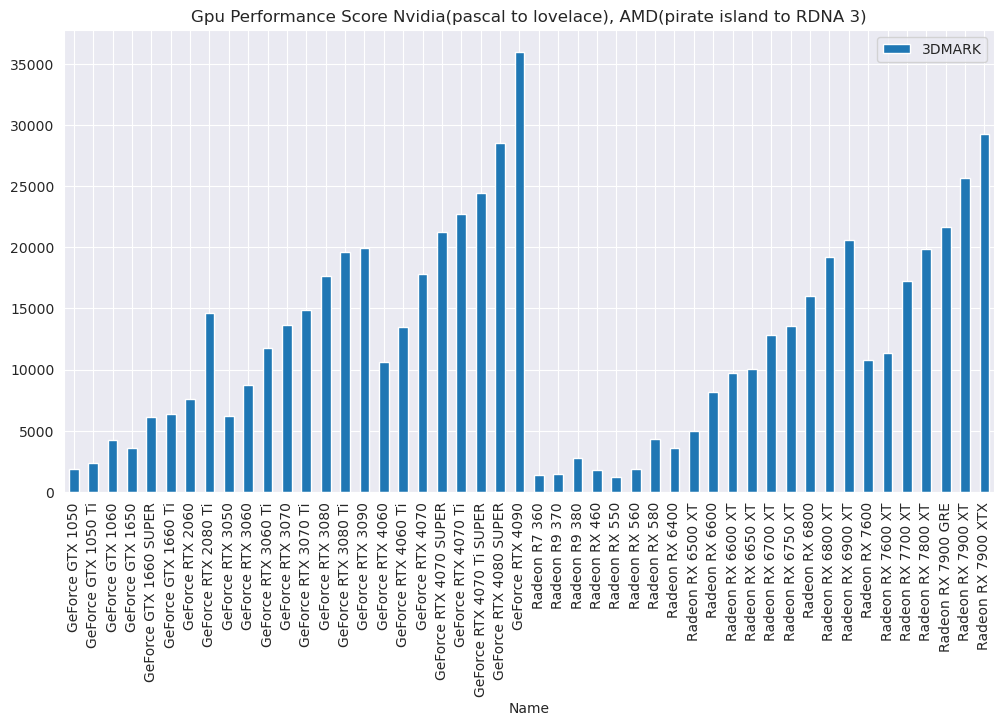

In [50]:
all_gpu_performance_data.set_index('Name').plot(figsize = (12,6), kind = 'bar')
plt.title("Gpu Performance Score Nvidia(pascal to lovelace), AMD(pirate island to RDNA 3)")

In [51]:
resale_price = historical_data.groupby(by="Name")[["Retail Price", "Used Price"]].mean()
resale_price = resale_price.reset_index()
full_dataset = pd.merge(resale_price, all_gpu_performance_data, how='left')
full_dataset.head()

,Name,Retail Price,Used Price,3DMARK
0,GeForce GTX 1050,224.888889,53.277778,1861
1,GeForce GTX 1050 Ti,190.500000,66.222222,2356
2,GeForce GTX 1060,290.937500,77.875000,4215
3,GeForce GTX 1650,147.423077,83.923077,3552
4,GeForce GTX 1660 SUPER,222.423077,105.461538,6078


In [52]:
drop_this = ['Name']
correlation_table = full_dataset.drop(columns=drop_this).corr()
correlation_table

,Retail Price,Used Price,3DMARK
Retail Price,1.000000,0.856729,0.822890
Used Price,0.856729,1.000000,0.936378
3DMARK,0.822890,0.936378,1.000000


In [53]:
full_dataset["Resale Value %"] = full_dataset["Used Price"]/full_dataset["Retail Price"]*100
full_dataset.head(10)

,Name,Retail Price,Used Price,3DMARK,Resale Value %
0,GeForce GTX 1050,224.888889,53.277778,1861,23.690711
1,GeForce GTX 1050 Ti,190.500000,66.222222,2356,34.762321
2,GeForce GTX 1060,290.937500,77.875000,4215,26.766917
3,GeForce GTX 1650,147.423077,83.923077,3552,56.926689
4,GeForce GTX 1660 SUPER,222.423077,105.461538,6078,47.414837
5,GeForce GTX 1660 Ti,305.307692,118.076923,6373,38.674729
6,GeForce RTX 2060,320.076923,145.115385,7601,45.337659
7,GeForce RTX 2080 Ti,1271.333333,307.666667,14628,24.200315
8,GeForce RTX 3050,234.769231,182.269231,6205,77.637615
9,GeForce RTX 3060,299.230769,225.269231,8739,75.282776


<Axes: title={'center': 'Retail vs Used Price'}, xlabel='Name'>

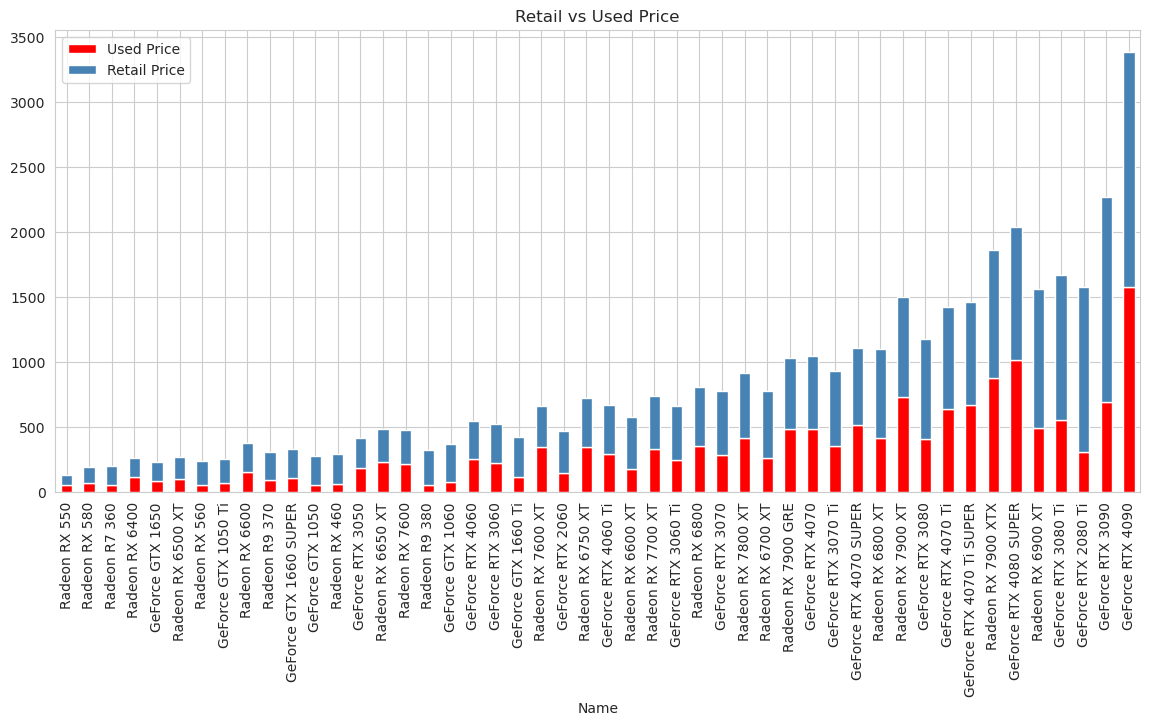

In [54]:
satacked_gpu_resale = full_dataset[["Name", "Used Price", "Retail Price"]]
satacked_gpu_resale = satacked_gpu_resale.sort_values("Retail Price")
sns.set_style("whitegrid")
satacked_gpu_resale.set_index('Name').plot(figsize = (14,6), kind='bar', stacked=True, color=['red', 'steelblue'], title = "Retail vs Used Price")

In [55]:
full_dataset["Price To Performance(NEW)"] = full_dataset["3DMARK"]//full_dataset["Retail Price"]
full_dataset["Price To Performance(OLD)"] = full_dataset["3DMARK"]//full_dataset["Used Price"]

<Axes: title={'center': 'Price to Performance(NEW vs OLD)'}, xlabel='Name'>

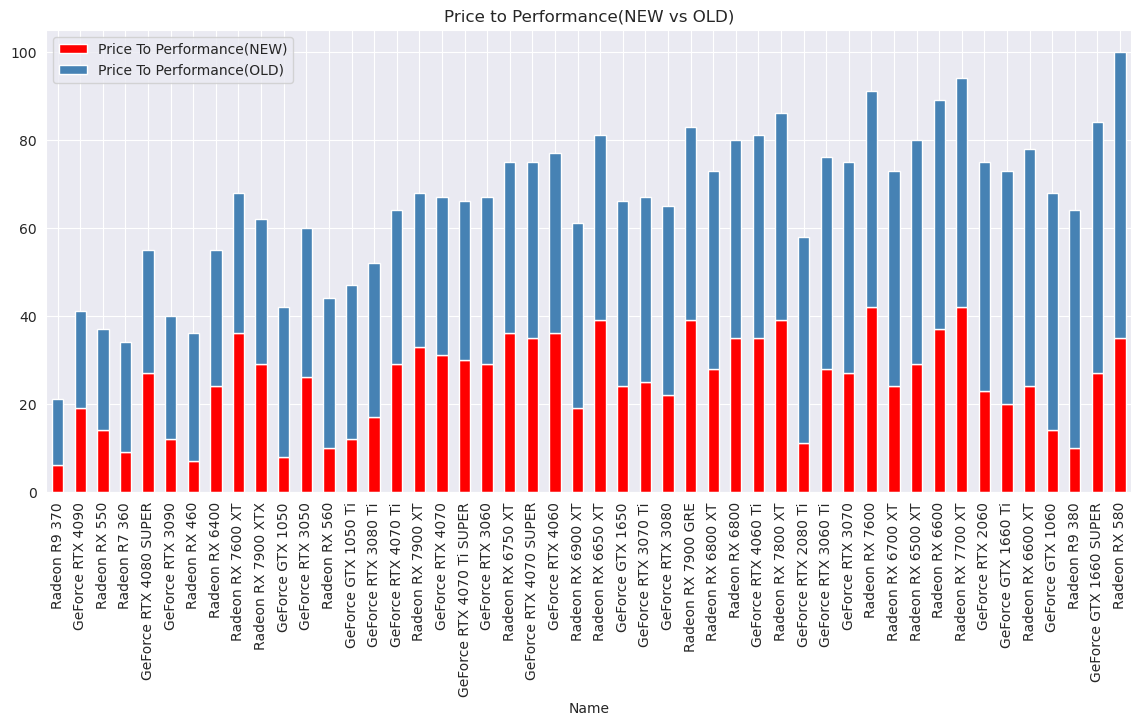

In [56]:
price_to_performance = full_dataset[["Name", "Price To Performance(NEW)", "Price To Performance(OLD)"]]
sns.set_style("darkgrid")
price_to_performance = price_to_performance.sort_values("Price To Performance(OLD)")
price_to_performance.set_index('Name').plot(figsize = (14,6), kind = 'bar', stacked = True, color = ['red', 'steelblue'], title = "Price to Performance(NEW vs OLD)")

In [57]:
fig = px.bar(price_to_performance.sort_values('Price To Performance(OLD)'), 
             x = 'Name', 
             y = ['Price To Performance(NEW)', 'Price To Performance(OLD)'], 
             width= 1400, 
             height=600, 
             barmode='stack', 
             title='Price To Performance(NEW vs OLD)',
             labels={'value': 'Performance Score', 'variable': 'Type'}
             )
fig.update_layout(xaxis_tickangle = -40)
fig.show()